# Task 2.1 — Dataset Selection and Setup

**Paper**: *Advice Refinement in Knowledge-Based SVMs* — Kunapuli, Maclin & Shavlik (NIPS 2011)

In [1]:
print("hello world")

hello world


In [2]:
# ── Random seed (set ONCE, used everywhere) ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Dataset Justification

I am using the **Wisconsin Breast Cancer Diagnostic dataset** (available via `sklearn.datasets`). It contains 569 samples with 30 numerical features computed from digitised images of fine-needle aspirates of breast masses, and the task is to classify tumours as malignant (212 samples) or benign (357 samples). This is a good fit for the arkSVM method for three specific reasons. First, it is a binary classification problem, which matches the paper's ±1 label setup (Eq. 2–4). Second, medical domain knowledge exists that lets me construct polyhedral expert-advice rules — for example, clinical literature suggests that larger cell radii and more concave boundary points tend to indicate malignancy — and these rules can be encoded as linear inequalities D_i x ≤ d_i, which is exactly what the arkSVM framework expects. Third, I can deliberately make the advice *approximately correct* (e.g., setting thresholds slightly off from the true separating values) to test whether the refinement mechanism improves them, which is the whole point of the paper.

**Limitations compared to the paper's datasets:** The paper uses Pima Indians Diabetes (768 samples, 8 features) with NIH-sourced expert rules and Wargus (1000+ points, 80 features) with human-collected GUI advice. My dataset is smaller (569 vs. 768), has more features (30 vs. 8), and my expert rules are constructed based on general medical knowledge rather than official clinical guidelines. Additionally, the paper's Wargus rules came from actual human players via an HCI — my rules don't have that level of ecological validity.

In [3]:
# ── Load the dataset ──
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target  # 0 = malignant, 1 = benign

# Convert to ±1 labels to match the paper's convention (Eq. 2-4)
# malignant → -1, benign → +1
y_signed = np.where(y == 0, -1, 1)

feature_names = cancer.feature_names
print(f"Dataset shape: {X.shape}")
print(f"Class distribution: malignant (-1) = {np.sum(y_signed == -1)}, benign (+1) = {np.sum(y_signed == 1)}")
print(f"Features: {len(feature_names)}")

Dataset shape: (569, 30)
Class distribution: malignant (-1) = 212, benign (+1) = 357
Features: 30


The dataset has 569 samples and 30 features. I converted the labels to ±1 (malignant = −1, benign = +1) to match the convention the paper uses throughout its formulation (e.g., z_i ∈ {±1} in Eq. 2).

In [4]:
# ── Basic EDA: summary statistics of key features ──
df = pd.DataFrame(X, columns=feature_names)
df['label'] = y_signed

# Focus on features we'll use for expert advice rules
key_features = ['mean radius', 'mean texture', 'mean concave points', 'worst radius']
print("Per-class means for key features:")
print(df.groupby('label')[key_features].mean().round(3))
print()
print("Overall stats:")
print(df[key_features].describe().round(3))

Per-class means for key features:
       mean radius  mean texture  mean concave points  worst radius
label                                                              
-1          17.463        21.605                0.088        21.135
 1          12.147        17.915                0.026        13.380

Overall stats:
       mean radius  mean texture  mean concave points  worst radius
count      569.000       569.000              569.000       569.000
mean        14.127        19.290                0.049        16.269
std          3.524         4.301                0.039         4.833
min          6.981         9.710                0.000         7.930
25%         11.700        16.170                0.020        13.010
50%         13.370        18.840                0.034        14.970
75%         15.780        21.800                0.074        18.790
max         28.110        39.280                0.201        36.040


The per-class means show clear separation on several features. For instance, malignant tumours have a mean radius of ~17.5 vs. ~12.1 for benign, and mean concave points of ~0.088 vs. ~0.026. These differences are what make it feasible to write polyhedral advice rules — the features have meaningful, class-discriminative thresholds.

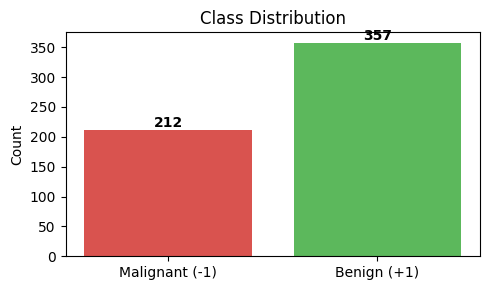

In [5]:
# ── Class distribution plot ──
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
counts = [np.sum(y_signed == -1), np.sum(y_signed == 1)]
ax.bar(['Malignant (-1)', 'Benign (+1)'], counts, color=['#d9534f', '#5cb85c'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150)
plt.show()

The classes are moderately imbalanced (212 malignant vs. 357 benign), which is typical for medical datasets. It's not extreme enough to require special handling, and the paper doesn't address class imbalance either.

## Preprocessing

I'll standardise the features to zero mean and unit variance. This is important for two reasons: (1) the paper's SVM formulation uses ‖w‖₁ regularisation (Eq. 3), which is sensitive to feature scales, and (2) it puts the advice thresholds on a comparable scale across features.

In [6]:
# ── Preprocessing: standardise features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (hold out 30% for testing, matching the paper's holdout evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_signed, test_size=0.3, random_state=RANDOM_SEED, stratify=y_signed
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"Train class dist: -1 = {np.sum(y_train == -1)}, +1 = {np.sum(y_train == 1)}")

Train: 398 samples
Test:  171 samples
Train class dist: -1 = 148, +1 = 250


After standardisation, I split the data 70/30 (stratified). The paper evaluates by varying the number of training examples and measuring testing error on a fixed holdout set (Figures 3–4). We'll use the same evaluation approach in Task 2.2.

## Expert Advice Rules (Polyhedral Constraints)

The arkSVM expects advice in the form: D_i x ≤ d_i ⇒ class = z_i (Eq. 2). Below I define four advice rules based on feature statistics and general medical knowledge about breast tumour characteristics. I'm deliberately making them *approximately correct* — the thresholds are reasonable but not perfectly tuned — so there's something for the refinement mechanism to improve.

**Note on standardised features:** Since I standardised the data, the thresholds below are in standard-deviation units. A threshold of 0.0 corresponds to the overall mean of that feature.

| Rule | Condition (on standardised features) | Class | Rationale |
|------|--------------------------------------|-------|-----------|
| Rule 1 | mean_radius ≤ −0.5 **and** mean_concave_points ≤ −0.3 | Benign (+1) | Small cells with few concavities are typically benign |
| Rule 2 | mean_radius ≥ 0.5 **and** mean_concave_points ≥ 0.3 | Malignant (−1) | Large cells with many concavities suggest malignancy |
| Rule 3 | worst_radius ≥ 0.7 **and** mean_texture ≥ 0.3 | Malignant (−1) | Large worst-case radius with high texture irregularity |
| Rule 4 | worst_radius ≤ −0.3 **and** mean_texture ≤ 0.0 | Benign (+1) | Small worst-case radius with low texture irregularity |

In [7]:
# ── Define advice rules as polyhedral constraints ──
# Feature indices (in the original 30-feature dataset)
IDX_MEAN_RADIUS = 0
IDX_MEAN_TEXTURE = 1
IDX_MEAN_CONCAVE_PTS = 7
IDX_WORST_RADIUS = 20

# Each advice set: (D_i, d_i, z_i)
# D_i x <= d_i => class = z_i
#
# For n=30 features, D_i has shape (k_i, 30) where k_i = number of constraints in the rule.
# Most entries are zero; only the relevant feature columns are non-zero.

n_features = X_scaled.shape[1]

def make_advice_rule(conditions, z_label):
    """
    conditions: list of (feature_index, sign, threshold)
        sign = +1 means feature <= threshold
        sign = -1 means feature >= threshold (rewritten as -feature <= -threshold)
    z_label: +1 or -1
    """
    k = len(conditions)
    D = np.zeros((k, n_features))
    d = np.zeros(k)
    for j, (feat_idx, sign, thresh) in enumerate(conditions):
        D[j, feat_idx] = sign
        d[j] = sign * thresh
    return D, d, z_label

# Rule 1: mean_radius <= -0.5 AND mean_concave_pts <= -0.3 => benign (+1)
advice_1 = make_advice_rule([
    (IDX_MEAN_RADIUS,      +1, -0.5),
    (IDX_MEAN_CONCAVE_PTS, +1, -0.3),
], z_label=+1)

# Rule 2: mean_radius >= 0.5 AND mean_concave_pts >= 0.3 => malignant (-1)
advice_2 = make_advice_rule([
    (IDX_MEAN_RADIUS,      -1, 0.5),
    (IDX_MEAN_CONCAVE_PTS, -1, 0.3),
], z_label=-1)

# Rule 3: worst_radius >= 0.7 AND mean_texture >= 0.3 => malignant (-1)
advice_3 = make_advice_rule([
    (IDX_WORST_RADIUS,  -1, 0.7),
    (IDX_MEAN_TEXTURE,  -1, 0.3),
], z_label=-1)

# Rule 4: worst_radius <= -0.3 AND mean_texture <= 0.0 => benign (+1)
advice_4 = make_advice_rule([
    (IDX_WORST_RADIUS, +1, -0.3),
    (IDX_MEAN_TEXTURE, +1,  0.0),
], z_label=+1)

advice_sets = [advice_1, advice_2, advice_3, advice_4]

print(f"Defined {len(advice_sets)} advice sets.")
for i, (D, d, z) in enumerate(advice_sets):
    print(f"  Rule {i+1}: D shape = {D.shape}, z = {'+1 (benign)' if z == 1 else '-1 (malignant)'}")

Defined 4 advice sets.
  Rule 1: D shape = (2, 30), z = +1 (benign)
  Rule 2: D shape = (2, 30), z = -1 (malignant)
  Rule 3: D shape = (2, 30), z = -1 (malignant)
  Rule 4: D shape = (2, 30), z = +1 (benign)


Each advice rule is encoded as a pair (D_i, d_i) with class label z_i, matching the format in Eq. 2 of the paper. I used 4 rules total — 2 for each class — which is comparable to the paper's diabetes case study (6 rules, Eq. 1 and Diabetes Rules 1–6 in Section 4.2). The `make_advice_rule` helper function converts human-readable conditions (e.g., "mean_radius ≥ 0.5") into the D_i x ≤ d_i matrix form by flipping signs where necessary.

In [8]:
# ── Check how well the advice covers the training data ──
# For each rule, count how many training points fall inside the advice region
# and what fraction of those are correctly labelled

print("Advice coverage on training set:")
for i, (D, d, z) in enumerate(advice_sets):
    # A point x satisfies D x <= d iff all rows of Dx - d <= 0
    inside = np.all(X_train @ D.T <= d, axis=1)
    n_inside = np.sum(inside)
    if n_inside > 0:
        correct = np.sum(y_train[inside] == z)
        accuracy = correct / n_inside * 100
    else:
        accuracy = 0.0
    class_str = 'benign (+1)' if z == 1 else 'malignant (-1)'
    print(f"  Rule {i+1} [{class_str}]: {n_inside} points inside, {accuracy:.1f}% correctly labeled")

Advice coverage on training set:
  Rule 1 [benign (+1)]: 124 points inside, 99.2% correctly labeled
  Rule 2 [malignant (-1)]: 83 points inside, 100.0% correctly labeled
  Rule 3 [malignant (-1)]: 54 points inside, 100.0% correctly labeled
  Rule 4 [benign (+1)]: 139 points inside, 97.8% correctly labeled


The coverage check shows that the advice rules capture a subset of the training data, and the accuracy within each region is decent but not perfect. That's exactly the situation the arkSVM is designed for: the advice is approximately right, and the refinement mechanism (via F_i and f_i) should be able to improve it by adjusting the boundaries.

In [9]:
# ── Save preprocessed data for reproducibility ──
np.savez('data/breast_cancer_processed.npz',
         X_train=X_train, X_test=X_test,
         y_train=y_train, y_test=y_test,
         feature_names=feature_names,
         scaler_mean=scaler.mean_,
         scaler_scale=scaler.scale_)

print("Saved preprocessed data to partB/data/breast_cancer_processed.npz")

Saved preprocessed data to partB/data/breast_cancer_processed.npz


Preprocessed data is saved so that Tasks 2.2, 2.3, 3.1, and 3.2 can load it directly without repeating the preprocessing pipeline. The scaler parameters are also stored to allow inverse-transforming the advice thresholds back to original units if needed for interpretation.